## Filter activation analysis — plots & motif sequences
Requires `filter_activation_analysis.py` to have been run first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from helper import (plot_filter_heatmap, 
                    top_activating_seqs, 
                    kernel_to_consensus,
                    plot_boxplots_references,
                    plot_boxplots_before_after,
                    plot_volcano)

In [2]:
OUTPUT_DIR = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundary_suppression/filter_activation_analysis"
TOP_K = 20

# Filters to print consensus sequences for
# Reverse complement will be shown for filters marked True
FILTERS_OF_INTEREST = {
    122: False,
     36: False,
    104: False,
     15: True,
    103: True,
}

## Load saved data

In [3]:
a1          = np.load(f"{OUTPUT_DIR}/activations_g1.npy")        # (n_seqs, n_filters)
a2          = np.load(f"{OUTPUT_DIR}/activations_g2.npy")
a3          = np.load(f"{OUTPUT_DIR}/activations_g3.npy")
a2_spatial  = np.load(f"{OUTPUT_DIR}/activations_g2_spatial.npy") # (n_seqs, n_filters, spatial)
seqs_g2     = np.load(f"{OUTPUT_DIR}/sequences_g2.npy")           # (n_seqs, 4, TARGET_LEN)
weights     = np.load(f"{OUTPUT_DIR}/conv_weights.npy")           # (n_filters, 4, kernel_size)
l4_g1       = np.load(f"{OUTPUT_DIR}/l4_acts_g1.npy")            # (n_seqs, n_filters, spatial)
l4_g2       = np.load(f"{OUTPUT_DIR}/l4_acts_g2.npy")
l4_g3       = np.load(f"{OUTPUT_DIR}/l4_acts_g3.npy")
l4_before   = np.load(f"{OUTPUT_DIR}/l4_acts_before.npy")
l4_after    = np.load(f"{OUTPUT_DIR}/l4_acts_after.npy")

KERNEL_SIZE = weights.shape[2]
print(f"First-layer activations:  {a1.shape}")
print(f"Layer-4 activations:      {l4_g1.shape}")
print(f"Before/after shapes:      {l4_before.shape} / {l4_after.shape}")
print(f"Conv weights:             {weights.shape}")

First-layer activations:  (300, 128)
Layer-4 activations:      (300, 128, 6)
Before/after shapes:      (323, 128, 64) / (323, 128, 64)
Conv weights:             (128, 4, 15)


## 1. Heatmap — top filters (1st conv layer) per group

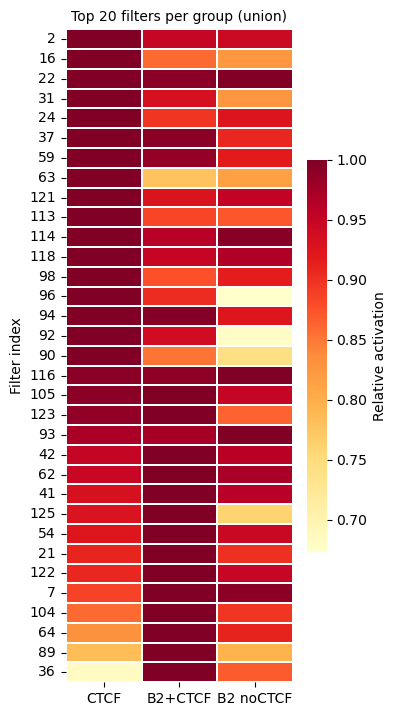

In [4]:
plot_filter_heatmap(a1, a2, a3)

## 2. Filter consensus sequences and top-activating B2+CTCF sequences

For each filter of interest:  
  - Consensus: argmax over base dimension of the learned Conv1d kernel.   
  - Top sequences: 3 B2+CTCF sequences with highest max activation; the 15 bp substring at the peak spatial position is extracted.   

Filters 15 and 103 are shown as reverse complement.  

In [5]:
N_TOP = 3

print(f"{'='*60}")
print(f"Kernel size = {KERNEL_SIZE} bp  |  top {N_TOP} B2+CTCF sequences per filter")
print(f"{'='*60}\n")

for filt_idx, use_rc in FILTERS_OF_INTEREST.items():
    strand_label = "reverse complement" if use_rc else "forward"
    consensus    = kernel_to_consensus(weights[filt_idx], use_rc=use_rc)
    hits         = top_activating_seqs(filt_idx, a2_spatial, seqs_g2,
                                        KERNEL_SIZE, n_top=N_TOP, use_rc=use_rc)
    print(f"Filter {filt_idx:3d}  [{strand_label}]")
    print(f"  Consensus:  {consensus}")
    print(f"  Top B2+CTCF sequences:")
    for rank, (seq_i, act, subseq) in enumerate(hits, 1):
        print(f"    {rank}. seq={seq_i:3d}  max_act={act:.4f}  {subseq}")
    print()

Kernel size = 15 bp  |  top 3 B2+CTCF sequences per filter

Filter 122  [forward]
  Consensus:  CAGTACCAGACCCGA
  Top B2+CTCF sequences:
    1. seq= 70  max_act=3.0425  CTGATTTCAATTCCC
    2. seq=283  max_act=2.7245  ACATGATGAGAGGCT
    3. seq=235  max_act=2.6767  CAGAGGTCCTGAGTT

Filter  36  [forward]
  Consensus:  GGTCCCGAACTTTAG
  Top B2+CTCF sequences:
    1. seq=124  max_act=2.4180  GAGGTCAAATTCCAA
    2. seq=211  max_act=2.3713  AGTTTAATTCCCAGC
    3. seq=298  max_act=2.3713  GAGTTTAATTTCCAG

Filter 104  [forward]
  Consensus:  CCATCATCTGGGGGG
  Top B2+CTCF sequences:
    1. seq= 40  max_act=2.6787  TCTGGGCTGATGCTG
    2. seq=155  max_act=2.4343  GTGGTTGCTGGGAAT
    3. seq=203  max_act=2.4343  GTGGTTGCTGGGATT

Filter  15  [reverse complement]
  Consensus:  TTCCGCCTACTGGAG
  Top B2+CTCF sequences:
    1. seq=272  max_act=2.5998  ATCCGATGCCGCCTT
    2. seq=174  max_act=2.5866  AATCTGATGCCTTCT
    3. seq= 22  max_act=2.5576  ATCTGATGCCGTCTT

Filter 103  [reverse complement]
  Consen

## 3. Layer-4 boxplots — filters 68 & 81

In [6]:
def maxpool(acts):
    return acts.max(axis=2) if acts.ndim == 3 else acts

mp1 = maxpool(l4_g1)   # (n_seqs, n_filters)
mp2 = maxpool(l4_g2)
mp3 = maxpool(l4_g3)

m1, m2, m3 = mp1.mean(0), mp2.mean(0), mp3.mean(0)

# Specificity: B2+CTCF mean activation minus the mean of the other two groups.
# Normalized by total mean activation to avoid selecting weakly-activated filters.
background = (m1 + m3) / 2
specificity = (m2 - background) / (m2 + background + 1e-8)

spec_df = pd.DataFrame({
    "filter_idx":   np.arange(len(m2)),
    "mean_B2CTCF":  m2,
    "mean_CTCF":    m1,
    "mean_B2noCTCF": m3,
    "specificity":  specificity,
}).sort_values("specificity", ascending=False)

print(spec_df.head(20).to_string(index=False))

B2_FILTERS = spec_df.head(TOP_K)["filter_idx"].tolist()
print(f"\nB2_FILTERS (top {TOP_K} by specificity): {B2_FILTERS}")

 filter_idx  mean_B2CTCF  mean_CTCF  mean_B2noCTCF  specificity
         81     2.052001   0.956927       1.546967     0.242151
         68     3.276452   2.458230       1.797147     0.212571
         72     1.999957   1.122928       1.768914     0.160782
         34     1.866447   0.585560       2.197545     0.145763
         44     1.322922   0.828822       1.160464     0.141648
        120     1.635467   1.211102       1.267926     0.137724
         22     2.640062   1.634589       2.368062     0.137618
         32     1.292247   0.853768       1.137679     0.129601
          9     1.902817   1.745714       1.241354     0.120507
         78     0.849046   0.549767       0.841965     0.099152
         27     2.267827   1.614329       2.148248     0.093162
         26     1.348015   0.987127       1.251829     0.092619
          1     1.066796   0.758234       1.015419     0.092121
         31     1.833544   1.305635       1.831616     0.077868
         37     1.708832   1.831294     

In [7]:
B2_FILTERS = [81, 68]

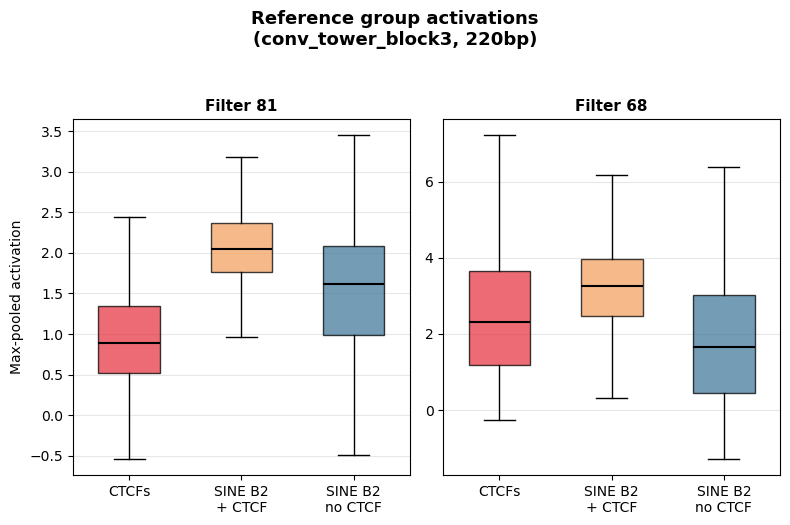

In [8]:
plot_boxplots_references(l4_g1, l4_g2, l4_g3, B2_FILTERS,
                         save_path=f"./../plots/boxplot_references.svg")

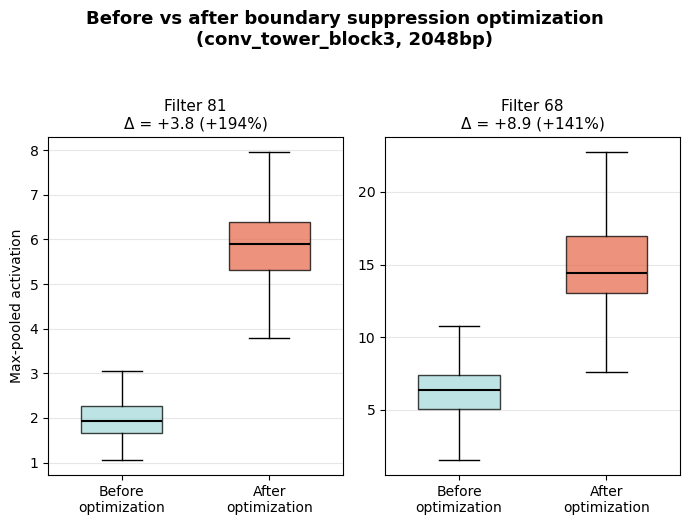

In [9]:
plot_boxplots_before_after(l4_before, l4_after, B2_FILTERS)

## 4. Volcano plot — all layer-4 filters, before vs after optimization

In [10]:
mp_before = maxpool(l4_before)
mp_after  = maxpool(l4_after)

deltas = mp_after.mean(0) - mp_before.mean(0)   # (n_filters,)
rank_order = np.argsort(deltas)[::-1]            # highest delta first

b2_ranks = pd.DataFrame({
    "filter_idx": B2_FILTERS,
    "delta_mean": [deltas[fi] for fi in B2_FILTERS],
    "rank":       [int(np.where(rank_order == fi)[0][0]) + 1 for fi in B2_FILTERS],
}).sort_values("rank")

n_filters = mp_before.shape[1]
print(f"B2+CTCF-specific filters ranked by activation change after suppression "
      f"(out of {n_filters}):\n")
print(b2_ranks.to_string(index=False))

# Highlight only those that also rank highly in the volcano (rank <= TOP_K)
top_highlight = b2_ranks[b2_ranks["rank"] <= TOP_K]["filter_idx"].tolist()
print(f"\nFilters in both top-{TOP_K} B2+CTCF-specific and top-{TOP_K} "
      f"post-suppression: {top_highlight}")

B2+CTCF-specific filters ranked by activation change after suppression (out of 128):

 filter_idx  delta_mean  rank
         68    8.931410     1
         81    3.818313     5

Filters in both top-20 B2+CTCF-specific and top-20 post-suppression: [68, 81]


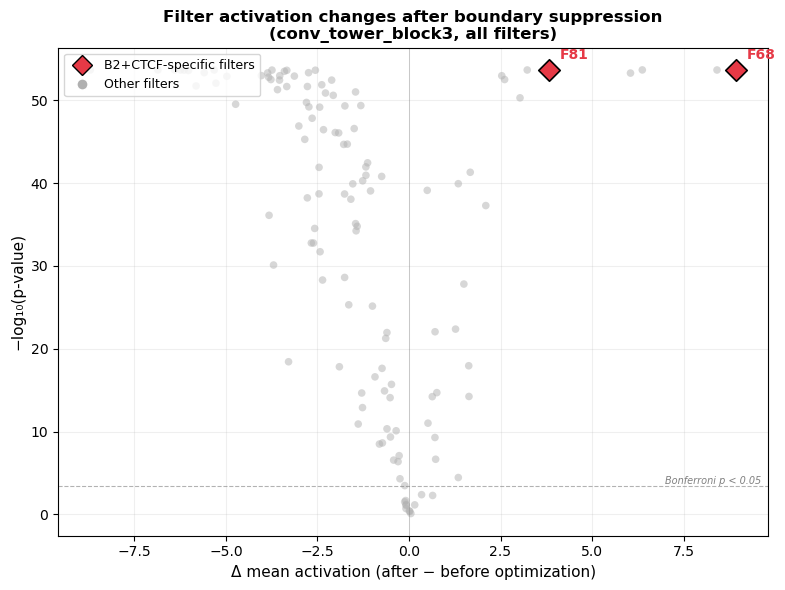


Highlighted filters:
  Filter 81: Δ=+3.82, p=2.24e-54, -log10(p)=53.7
  Filter 68: Δ=+8.93, p=2.24e-54, -log10(p)=53.7

Rank of highlighted filters (by Δ, descending):
  Filter 81: rank 5/128
  Filter 68: rank 1/128


In [11]:
plot_volcano(l4_before, l4_after, highlight_filters=B2_FILTERS,
             save_path=f"./../plots/volcano_layer4.svg")